# Phase 1: PBMC4k quality control and preprocessing

This notebook converts the official 10x Genomics PBMC4k filtered count matrix into a reproducible, analysis-ready AnnData object. It mirrors the PBMC3k quality-control workflow while requiring the PBMC4k distributions to be reviewed before filtering.

The notebook performs only Phase 1 work:

- extract and load the downloaded filtered count matrix;
- preserve original counts;
- calculate and inspect cell-level QC metrics;
- filter cells and poorly detected genes after threshold review;
- normalize and log-transform expression;
- calculate a PBMC4k-only standard-deviation ranking without discarding genes;
- save the full normalized gene matrix for later PBMC3k/PBMC4k integration.

It does **not** run PCA, Harmony, neighbors, UMAP, clustering, marker annotation, model training, or classification.

## Data source and interpretation boundary

The input is the filtered gene-by-cell matrix from the [10x Genomics PBMC4k Cell Ranger 2.1.0 dataset](https://www.10xgenomics.com/datasets/4-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0).

Cell Ranger's filtered matrix contains barcodes it identified as cells. That filtering does not replace dataset-specific QC. Conversely, the thresholds used for PBMC3k must not be copied blindly because sequencing depth, chemistry, reference, and processing can shift the distributions.

## 1. Imports and reproducible settings

In [1]:
from pathlib import Path
import tarfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display
from scipy import sparse

sc.set_figure_params(dpi=100, facecolor="white")
ad.settings.allow_write_nullable_strings = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Locate the PBMC4k project and downloaded archive

The path search supports kernels started from the repository root, `PBMC4k/`, or `PBMC4k/notebooks/`. The archive remains under `data/raw/`. Extraction also occurs under `data/raw/`, preserving the original download.

In [2]:
cwd = Path.cwd().resolve()
project_candidates = []
for base in (cwd, *cwd.parents):
    project_candidates.extend(
        (
            base,
            base / "PBMC4k",
            base / "26-the-backpropagators-analysis" / "PBMC4k",
        )
    )

PROJECT = next(
    (
        candidate
        for candidate in project_candidates
        if (candidate / "data" / "raw" / "pbmc4k_filtered_gene_bc_matrices.tar.gz").is_file()
    ),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Could not locate PBMC4k/data/raw/pbmc4k_filtered_gene_bc_matrices.tar.gz"
    )

RAW = PROJECT / "data" / "raw"
ARCHIVE = RAW / "pbmc4k_filtered_gene_bc_matrices.tar.gz"
FILTERED = RAW / "filtered_gene_bc_matrices" / "GRCh38"
PROCESSED = PROJECT / "data" / "processed"

print("PBMC4k project:", PROJECT)
print("Downloaded archive:", ARCHIVE)
print("Expected extracted matrix:", FILTERED)

PBMC4k project: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k
Downloaded archive: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/raw/pbmc4k_filtered_gene_bc_matrices.tar.gz
Expected extracted matrix: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/raw/filtered_gene_bc_matrices/GRCh38


## 3. Reviewed QC parameters

These thresholds were reviewed against the PBMC4k QC distributions. The mitochondrial cutoff was set to 8% because the median was 2.85%, the 95th percentile was 5.89%, and the 99th percentile was 7.92%. This removes the unusually high mitochondrial tail without using the stricter 5% starting value, which would remove about 11% of the cells.

| Setting | Candidate value | Purpose |
|---|---:|---|
| Minimum genes per cell | 200 | Remove cells or droplets with very little detected RNA |
| Maximum genes per cell | 2,500 | Flag unusually complex cells and possible doublets |
| Maximum mitochondrial percentage | 8% | Remove the unusually high mitochondrial tail associated with stressed or damaged cells |
| Minimum cells per gene | 3 | Remove genes with too little detection evidence |
| Normalized total per cell | 10,000 | Make retained cell totals comparable |
| PBMC4k-only SD ranking size | 2,000 | Record a comparable ranking without subsetting integration input |

The maximum-gene rule is only a simple doublet heuristic. This notebook does not claim to perform formal doublet detection.

In [3]:
MIN_GENES_PER_CELL = 200
MAX_GENES_PER_CELL = 2_500
MAX_MT_PERCENT = 8.0
MIN_CELLS_PER_GENE = 3
NORMALIZATION_TARGET = 10_000
N_TOP_SD_GENES = 2_000

# Reviewed against the PBMC4k QC summaries and plots on 2026-07-29.
THRESHOLDS_REVIEWED = True

parameters = pd.Series(
    {
        "minimum genes per cell": MIN_GENES_PER_CELL,
        "maximum genes per cell": MAX_GENES_PER_CELL,
        "maximum mitochondrial percent": MAX_MT_PERCENT,
        "minimum cells per gene": MIN_CELLS_PER_GENE,
        "normalization target": NORMALIZATION_TARGET,
        "genes flagged by PBMC4k-only SD rank": N_TOP_SD_GENES,
        "thresholds reviewed": THRESHOLDS_REVIEWED,
    },
    name="value",
)
display(parameters.to_frame())

,value
minimum genes per cell,200
maximum genes per cell,2500
maximum mitochondrial percent,8.0
minimum cells per gene,3
normalization target,10000
genes flagged by PBMC4k-only SD rank,2000
thresholds reviewed,True


## 4. Extract the official filtered matrix if necessary

This cell extracts the downloaded archive only when the expected `GRCh38` matrix directory is absent. It rejects archive members that would escape the raw-data directory. Extraction is not data cleaning and does not alter the downloaded archive.

In [4]:
if not FILTERED.is_dir():
    raw_root = RAW.resolve()
    with tarfile.open(ARCHIVE, mode="r:gz") as archive:
        for member in archive.getmembers():
            destination = (RAW / member.name).resolve()
            if not destination.is_relative_to(raw_root):
                raise ValueError(f"Unsafe archive member: {member.name}")
        archive.extractall(RAW)
    print("Extracted:", ARCHIVE.name)
else:
    print("Using existing extracted matrix:", FILTERED)

if not FILTERED.is_dir():
    raise FileNotFoundError(f"Expected extracted matrix directory was not found: {FILTERED}")

Using existing extracted matrix: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/raw/filtered_gene_bc_matrices/GRCh38


## 5. Load the filtered count matrix

Rows become cells and columns become genes. Gene symbols are used as display names while the original Ensembl identifiers remain available in `adata.var['gene_ids']`. Original counts are preserved before any transformation.

In [5]:
adata = sc.read_10x_mtx(FILTERED, var_names="gene_symbols", cache=False)
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.layers["counts"] = adata.X.copy()
adata.obs["dataset"] = "PBMC4k"
adata.obs["original_barcode"] = adata.obs_names.astype(str)
adata.obs_names = "pbmc4k_" + adata.obs_names.astype(str)
adata.obs_names_make_unique()

print(adata)
print(f"Starting cells: {adata.n_obs:,}")
print(f"Starting genes: {adata.n_vars:,}")
print("Original counts preserved:", "counts" in adata.layers)

AnnData object with n_obs × n_vars = 4340 × 33694
    obs: 'dataset', 'original_barcode'
    var: 'gene_ids'
    layers: 'counts'
Starting cells: 4,340
Starting genes: 33,694
Original counts preserved: True


## 6. Calculate unfiltered QC metrics

- `total_counts`: total RNA/UMI counts detected in a cell.
- `n_genes_by_counts`: genes with at least one detected count.
- `pct_counts_mt`: percentage of counts assigned to mitochondrial genes.

An unusually high mitochondrial percentage can indicate a damaged or stressed cell. High gene complexity can indicate a doublet, but complexity alone is not definitive.

In [6]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

qc_columns = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
display(adata.obs[qc_columns].describe().T)

quantiles = adata.obs[qc_columns].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(quantiles)

,count,mean,std,min,25%,50%,75%,max
total_counts,4340.0,4349.037598,2352.224365,1386.000000,3070.750000,3866.500000,4906.250000,48443.000000
n_genes_by_counts,4340.0,1319.745392,463.436009,498.000000,1050.000000,1235.000000,1462.000000,5251.000000
pct_counts_mt,4340.0,3.215936,1.593085,0.162955,2.231718,2.846002,3.849218,33.468765


,total_counts,n_genes_by_counts,pct_counts_mt
0.01,1505.39,610.39,1.081852
0.05,1907.80,753.95,1.556277
0.25,3070.75,1050.00,2.231718
0.50,3866.50,1235.00,2.846002
0.75,4906.25,1462.00,3.849218
0.95,8386.05,2213.15,5.894281
0.99,13938.53,3095.83,7.917891


## 7. Inspect PBMC4k QC distributions

Review these plots before filtering. The dashed lines show the current candidate thresholds; they are not automatically justified by their use in PBMC3k.

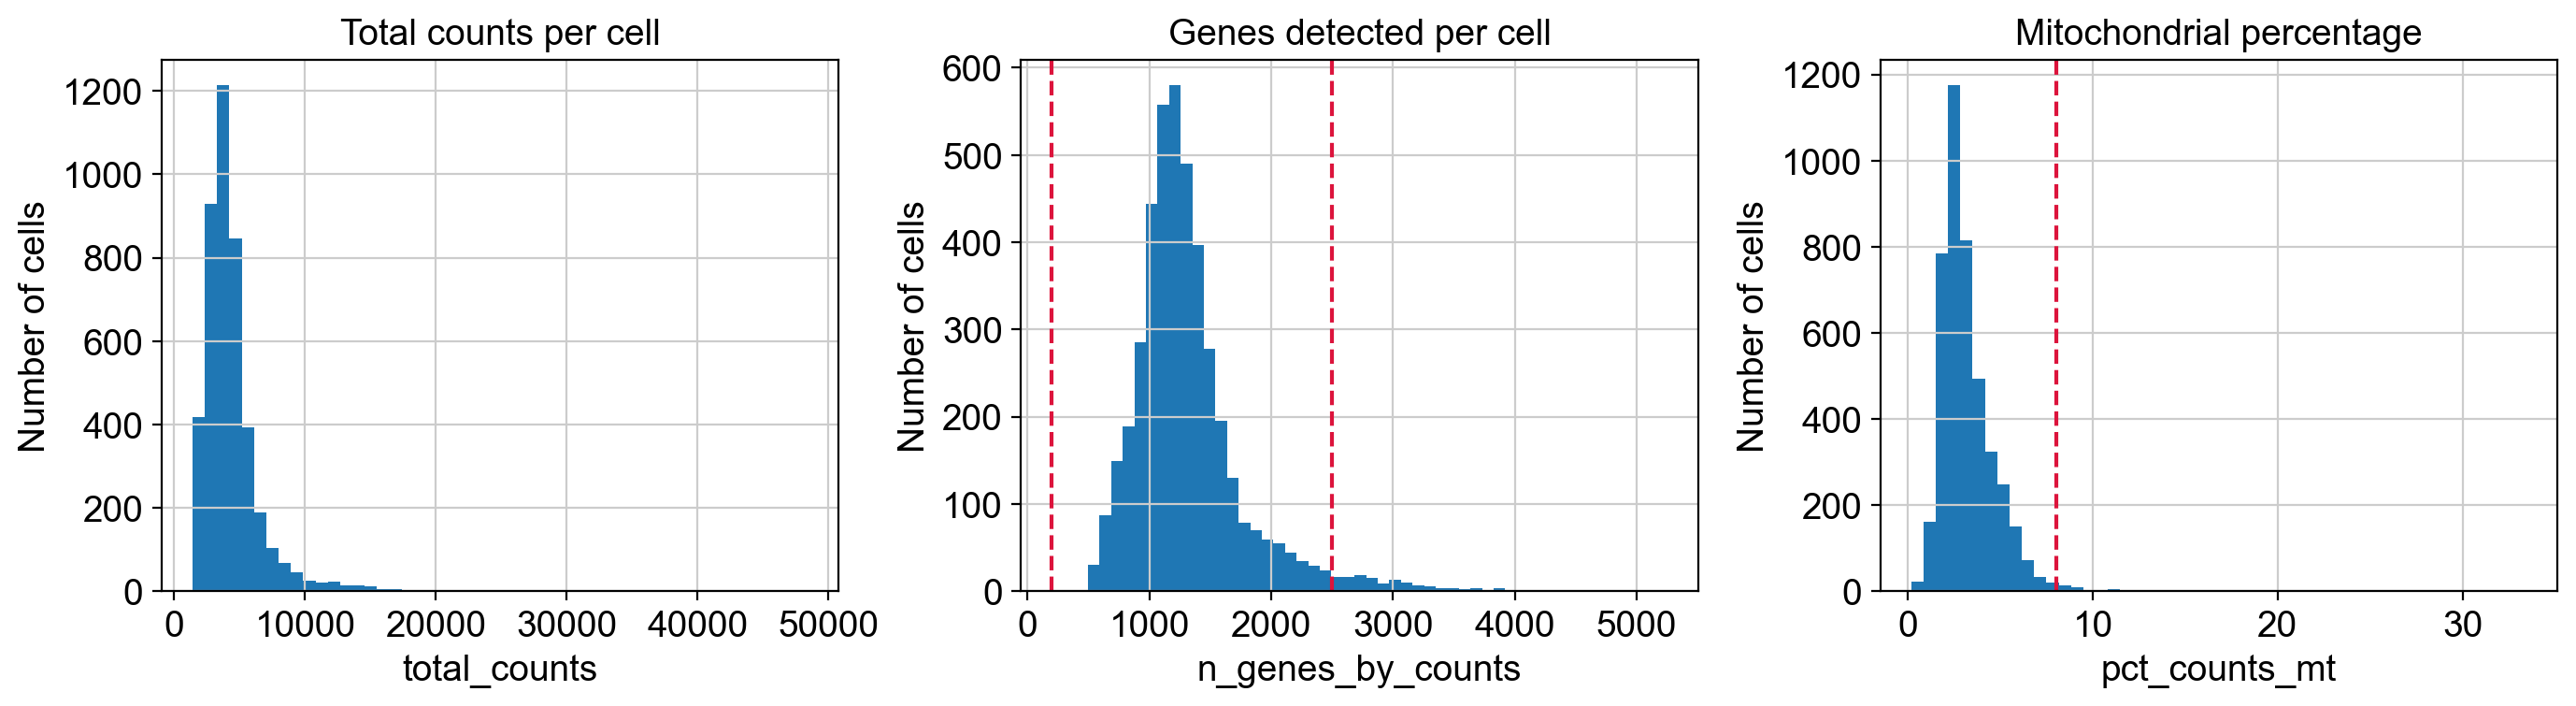

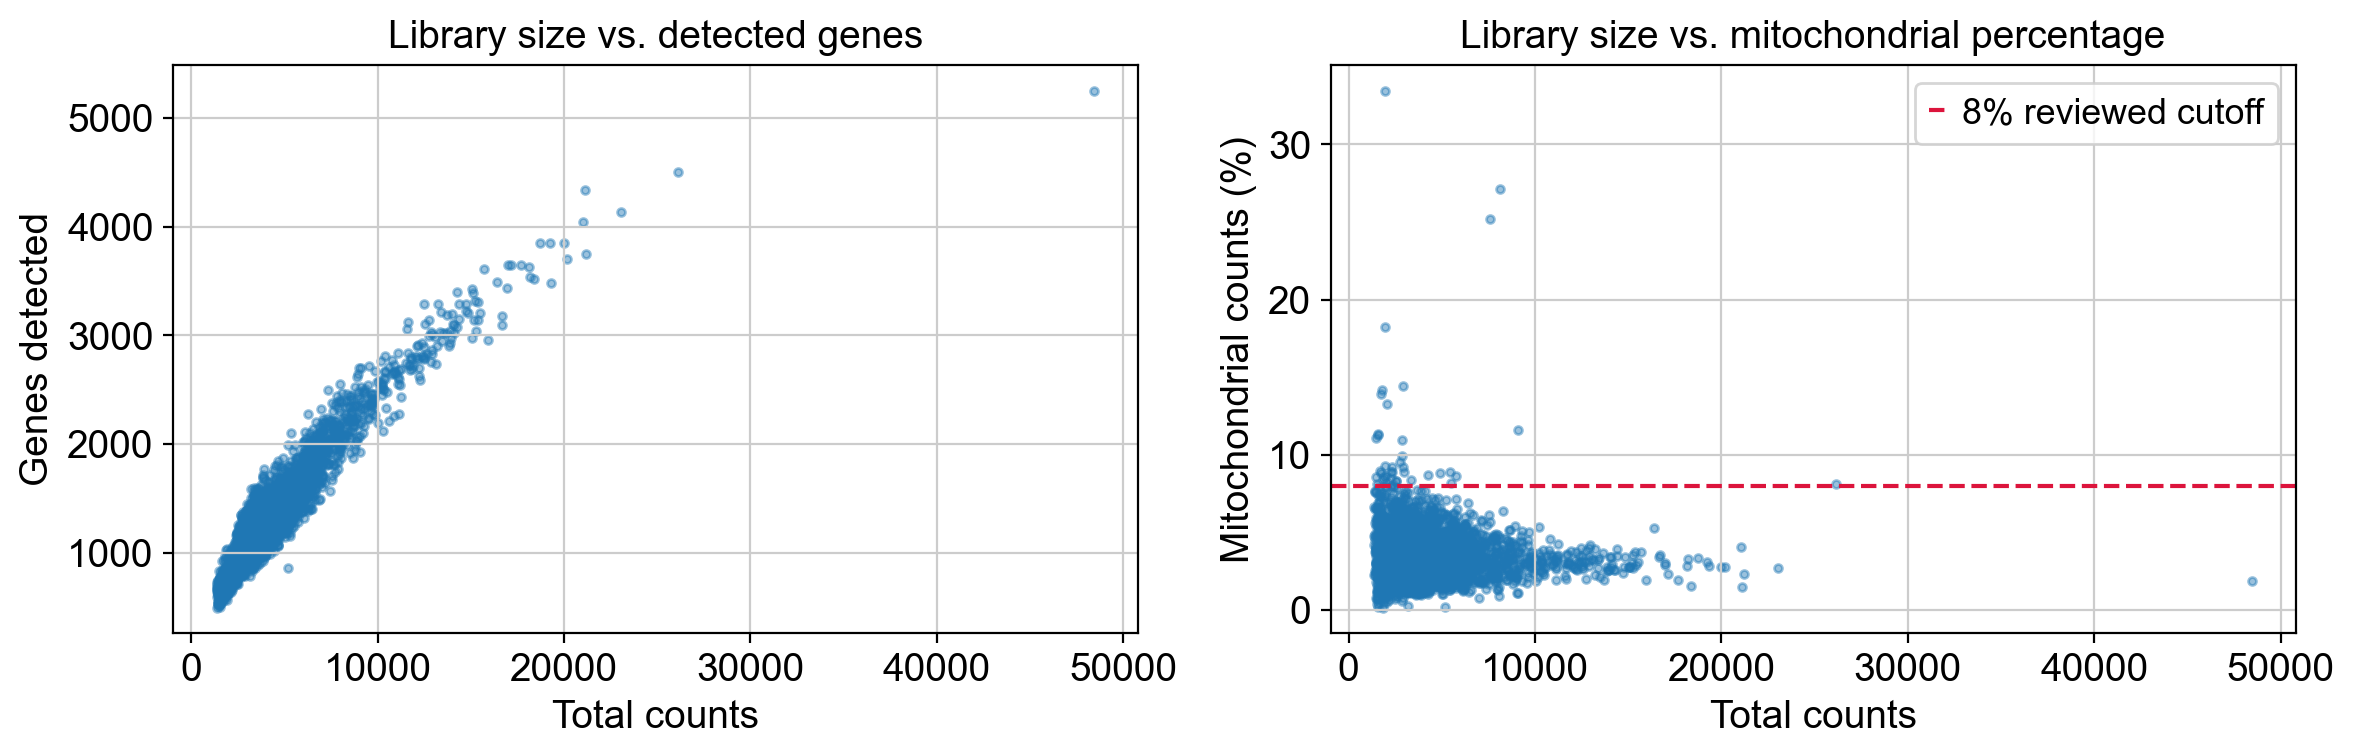

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column, title in zip(
    axes,
    qc_columns,
    ["Total counts per cell", "Genes detected per cell", "Mitochondrial percentage"],
):
    axis.hist(adata.obs[column], bins=50)
    axis.set(xlabel=column, ylabel="Number of cells", title=title)

axes[1].axvline(MIN_GENES_PER_CELL, color="crimson", linestyle="--")
axes[1].axvline(MAX_GENES_PER_CELL, color="crimson", linestyle="--")
axes[2].axvline(MAX_MT_PERCENT, color="crimson", linestyle="--")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    adata.obs["total_counts"],
    adata.obs["n_genes_by_counts"],
    s=8,
    alpha=0.45,
)
axes[0].set(
    xlabel="Total counts",
    ylabel="Genes detected",
    title="Library size vs. detected genes",
)
axes[1].scatter(
    adata.obs["total_counts"],
    adata.obs["pct_counts_mt"],
    s=8,
    alpha=0.45,
)
axes[1].axhline(
    MAX_MT_PERCENT,
    color="crimson",
    linestyle="--",
    label=f"{MAX_MT_PERCENT:g}% reviewed cutoff",
)
axes[1].set(
    xlabel="Total counts",
    ylabel="Mitochondrial counts (%)",
    title="Library size vs. mitochondrial percentage",
)
axes[1].legend()
plt.tight_layout()
plt.show()

## Required threshold review

Review completed on 2026-07-29:

1. The mitochondrial median was 2.85%, the 95th percentile was 5.89%, and the 99th percentile was 7.92%.
2. A 5% cutoff would remove 482 of 4,340 cells (11.1%), so it was judged too strict for this dataset.
3. `MAX_MT_PERCENT` was set to 8% to remove the unusually high tail.
4. The 200 minimum-gene and 2,500 maximum-gene thresholds were retained.
5. `THRESHOLDS_REVIEWED` is set to `True`, allowing the filtering section to run.

If the thresholds are changed later, review the distributions again and update this justification.

## 8. Apply reviewed cell and gene filters

Every cell receives explicit pass/fail flags before subsetting. The summary counts failures for each rule; one cell can fail more than one rule. Genes are filtered only after cell QC.

In [8]:
if not THRESHOLDS_REVIEWED:
    raise RuntimeError(
        "Review the PBMC4k QC distributions, update thresholds if needed, "
        "then set THRESHOLDS_REVIEWED = True before filtering."
    )

adata.obs["pass_min_genes"] = adata.obs["n_genes_by_counts"] >= MIN_GENES_PER_CELL
adata.obs["pass_max_genes"] = adata.obs["n_genes_by_counts"] < MAX_GENES_PER_CELL
adata.obs["pass_mt"] = adata.obs["pct_counts_mt"] < MAX_MT_PERCENT
adata.obs["pass_qc"] = adata.obs[
    ["pass_min_genes", "pass_max_genes", "pass_mt"]
].all(axis=1)

cell_filter_summary = pd.Series(
    {
        "starting cells": adata.n_obs,
        "below minimum genes": int((~adata.obs["pass_min_genes"]).sum()),
        "at/above maximum genes": int((~adata.obs["pass_max_genes"]).sum()),
        "at/above mitochondrial cutoff": int((~adata.obs["pass_mt"]).sum()),
        "cells passing all QC rules": int(adata.obs["pass_qc"].sum()),
    },
    name="cells",
)
display(cell_filter_summary.to_frame())

starting_cells, starting_genes = adata.shape
adata = adata[adata.obs["pass_qc"]].copy()
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

filter_results = pd.DataFrame(
    {
        "before QC": [starting_cells, starting_genes],
        "after QC": [adata.n_obs, adata.n_vars],
        "removed": [starting_cells - adata.n_obs, starting_genes - adata.n_vars],
    },
    index=["cells", "genes"],
)
display(filter_results)
display(adata.obs[qc_columns].describe().T)

,cells
starting cells,4340
below minimum genes,0
at/above maximum genes,132
at/above mitochondrial cutoff,40
cells passing all QC rules,4169


,before QC,after QC,removed
cells,4340,4169,171
genes,33694,16361,17333


,count,mean,std,min,25%,50%,75%,max
total_counts,4169.0,4070.540771,1536.968750,1385.000000,3064.00000,3824.000000,4788.000000,11248.000000
n_genes_by_counts,4169.0,1267.807148,348.635942,498.000000,1046.00000,1227.000000,1432.000000,2494.000000
pct_counts_mt,4169.0,3.144501,1.307182,0.163399,2.20765,2.818218,3.833107,7.970297


## 9. Normalize and log-transform expression

Total-count normalization scales every retained cell to the same target total. `log1p` compresses the expression range while preserving zero values. The original filtered counts remain in `adata.layers['counts']`.

In [9]:
sc.pp.normalize_total(adata, target_sum=NORMALIZATION_TARGET)
sc.pp.log1p(adata)

print("Normalized totals target:", f"{NORMALIZATION_TARGET:,}")
print("Transformation metadata:", adata.uns["log1p"])
print("Original counts preserved:", "counts" in adata.layers)

Normalized totals target: 10,000
Transformation metadata: {'base': None}
Original counts preserved: True


## 10. Record a PBMC4k-only standard-deviation ranking

For comparison with PBMC3k, this notebook ranks genes by population standard deviation after QC, normalization, and `log1p`. The top 2,000 receive a flag, but the main matrix is **not** subset. Later Harmony analysis should select integration features jointly across PBMC3k and PBMC4k with dataset awareness.

In [10]:
expression = adata.X
if sparse.issparse(expression):
    gene_mean = np.asarray(expression.mean(axis=0)).ravel()
    gene_mean_square = np.asarray(expression.power(2).mean(axis=0)).ravel()
else:
    dense_expression = np.asarray(expression)
    gene_mean = dense_expression.mean(axis=0)
    gene_mean_square = np.square(dense_expression).mean(axis=0)

gene_variance = np.maximum(gene_mean_square - np.square(gene_mean), 0)
gene_std = np.sqrt(gene_variance)

adata.var["expression_mean"] = gene_mean
adata.var["expression_std"] = gene_std
adata.var["std_rank"] = (
    pd.Series(gene_std, index=adata.var_names)
    .rank(method="first", ascending=False)
    .astype(int)
)
adata.var["selected_by_pbmc4k_std"] = (
    adata.var["std_rank"] <= min(N_TOP_SD_GENES, adata.n_vars)
)

ranked_genes = adata.var[
    ["gene_ids", "expression_mean", "expression_std", "std_rank", "selected_by_pbmc4k_std"]
].sort_values("std_rank")
display(ranked_genes.head(25))
print(
    f"Flagged {int(adata.var['selected_by_pbmc4k_std'].sum()):,} genes; "
    f"retained all {adata.n_vars:,} genes in the main matrix."
)

,gene_ids,expression_mean,expression_std,std_rank,selected_by_pbmc4k_std
LYZ,ENSG00000090382,1.714570,1.850096,1,True
S100A9,ENSG00000163220,1.758625,1.766340,2,True
S100A8,ENSG00000143546,1.560128,1.758246,3,True
HLA-DRA,ENSG00000204287,1.877970,1.616038,4,True
TYROBP,ENSG00000011600,1.285738,1.534324,5,True
CST3,ENSG00000101439,1.308658,1.470439,6,True
CD74,ENSG00000019582,2.596005,1.423128,7,True
HLA-DRB1,ENSG00000196126,1.420555,1.380750,8,True
S100A4,ENSG00000196154,2.362924,1.371833,9,True
CCL5,ENSG00000271503,0.829000,1.364311,10,True


Flagged 2,000 genes; retained all 16,361 genes in the main matrix.


## 11. Save the full Phase 1 result

The saved object retains every gene passing the minimum-cell filter. Its main matrix and `.raw` contain normalized log-expression, while `layers['counts']` contains the corresponding original counts. This full feature space is required for later shared-gene alignment and batch-aware feature selection.

The processed file is Git-ignored and can be regenerated from the official archive and this notebook.

In [11]:
PROCESSED.mkdir(parents=True, exist_ok=True)
adata.raw = adata.copy()

output_path = PROCESSED / "pbmc4k_phase1_qc_normalized.h5ad"

# Omitting log1p['base']=None still means Scanpy used the natural logarithm
# and avoids compatibility problems across AnnData versions.
if isinstance(adata.uns.get("log1p"), dict) and adata.uns["log1p"].get("base") is None:
    del adata.uns["log1p"]["base"]

adata.write_h5ad(output_path, compression="gzip")

phase1_summary = pd.Series(
    {
        "starting cells": starting_cells,
        "QC-passing cells": adata.n_obs,
        "starting genes": starting_genes,
        "genes after detection filter": adata.n_vars,
        "PBMC4k-only SD flags": int(adata.var["selected_by_pbmc4k_std"].sum()),
        "main-matrix genes retained": adata.n_vars,
        "normalization target": NORMALIZATION_TARGET,
        "output": str(output_path),
    },
    name="Phase 1 result",
)
display(phase1_summary.to_frame())
print(f"Saved {output_path.name} ({output_path.stat().st_size / 1024**2:.1f} MB)")

,Phase 1 result
starting cells,4340
QC-passing cells,4169
starting genes,33694
genes after detection filter,16361
PBMC4k-only SD flags,2000
main-matrix genes retained,16361
normalization target,10000
output,/Users/Ema/Desktop/cosmos/26-the-backpropagato...


Saved pbmc4k_phase1_qc_normalized.h5ad (39.2 MB)


## Phase 1 completion checklist

Phase 1 is complete only when:

- the official filtered matrix loads successfully;
- every cell- and gene-removal rule is documented;
- the PBMC4k QC distributions have been reviewed;
- the chosen thresholds have a written justification;
- original counts remain in `layers['counts']`;
- all normalized retained genes remain available;
- `pbmc4k_phase1_qc_normalized.h5ad` is saved and can be read back.

The next project phase should process PBMC3k and PBMC4k compatibility, construct an uncorrected combined baseline, and only then run Harmony. It should not use the PBMC4k-only top-2,000 flag as the final integration feature set.